# Data Analysis
This notebook is used to analyze the data collected from live runs. It includes various visualizations and statistical analyses to understand the performance of the runner

## TOC:

## Load the Dataset and Perform any Preprocessing

In [1]:
from utilis.helper import extract_global_json, extract_json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from scipy.signal import savgol_filter
# add categorical weather conditions
def add_weather_conditions(df, flat):
    # Create categorical weather conditions based on continuous variables
    df['temp_category'] = pd.cut([flat['temp']] * len(df), 
                                  bins=[0, 15, 25, 35], 
                                  labels=['Cold', 'Moderate', 'Hot'])
    
    df['humidity_category'] = pd.cut([flat['humidity']] * len(df), 
                                      bins=[0, 40, 70, 100], 
                                      labels=['Low', 'Medium', 'High'])

    df["dew_category"] = pd.cut([flat['dew']] * len(df), 
                                  bins=[0, 5, 10, 15, 20], 
                                  labels=['Low', 'Medium', 'High', 'Very High'])
    df["uvindex_category"] = pd.cut([flat['uvindex']] * len(df), 
                                      bins=[-1, 3, 6, 9, 12], 
                                      labels=['Low', 'Moderate', 'High', 'Very High'])

    # Create time-based categories
    df['time_category'] = pd.cut(df['time_datetime'].dt.hour, 
                                bins=[0, 6, 12, 18, 24], 
                                labels=['Night', 'Morning', 'Afternoon', 'Evening'])
    
    return df
# =========
# Load all series
# =========
output_folder = extract_global_json('output_folder')
dataframes = []

# loop through each dataset
for folder_name in os.listdir(output_folder):
    csv_file_path = os.path.join(output_folder, folder_name, f"{folder_name}_streams.csv")
    json_file_path = os.path.join(output_folder, folder_name, f"{folder_name}_overall.json")
    # get the csv_file into a DataFrame
    df = pd.read_csv(csv_file_path, parse_dates=["time_datetime"])
    overall_data = extract_json(json_file_path)

    df["series_id"] = folder_name  # Identify which series

    # Flatten weather dict if present
    flat = overall_data.copy()
    if "weather" in flat and isinstance(flat["weather"], dict):
        for k, v in flat["weather"].items():
            flat[f"{k}"] = v
        del flat["weather"]

    # add categorical weather conditions
    df = add_weather_conditions(df, flat)

    dataframes.append(df)

data = pd.concat(dataframes).sort_values(["series_id", "time_datetime"])

# =========
# Perform some basic preprocessing
# =========

# Remove unnecessary columns
data = data.drop(columns=[
    "moving", 
    "is_original", 
    "pace_efficiency" 
    # "smooth_pace_efficiency", 
    # "diff_pace_efficiency"
    ])

# Fill missing values within each series to prevent data leakage across series
data["smooth_pace_efficiency"] = data.groupby("series_id")["smooth_pace_efficiency"].ffill().bfill()
data["diff_pace_efficiency"] = data.groupby("series_id")["diff_pace_efficiency"].fillna(0)
data["relative_winddir_degree"] = data.groupby("series_id")["relative_winddir_degree"].ffill().bfill()
data["headwind_mps"] = data.groupby("series_id")["headwind_mps"].ffill().bfill()
data["crosswind_mps"] = data.groupby("series_id")["crosswind_mps"].ffill().bfill()
data["stride_length_m"] = data.groupby("series_id")["stride_length_m"].ffill().bfill()
data["smooth_headwind_mps"] = data.groupby("series_id")["smooth_headwind_mps"].ffill().bfill()
data["smooth_crosswind_mps"] = data.groupby("series_id")["smooth_crosswind_mps"].ffill().bfill()


# =========
# Encode series_id
# =========
# Define ordinal mappings with meaningful order
ordinal_mappings = {
    'temp_category': ['Cold', 'Moderate', 'Hot'],
    'humidity_category': ['Low', 'Medium', 'High'],
    'dew_category': ['Low', 'Medium', 'High', 'Very High'],
    "uvindex_category": ['Low', 'Moderate', 'High', 'Very High'],
}

for col, categories in ordinal_mappings.items():
    # if "category" in col and col in ordinal_mappings:
    encoder = OrdinalEncoder(categories=[categories]) 
    data[f"{col}_enc"] = encoder.fit_transform(data[[col]])

# Add date features (optional)
data["month"] = data["time_datetime"].dt.month
data["dayofweek"] = data["time_datetime"].dt.dayofweek
data["time_s"] = df.groupby("series_id")["time_datetime"].transform(lambda x: (x - x.iloc[0]).dt.total_seconds())

# Cumulative Elevtion Gain
data["cumulative_elevation_gain_m"] = data.groupby("series_id")["diff_altitude_mps"].transform(lambda x: x.clip(lower=0).cumsum()).fillna(0)

# Cumulative Headwind
# data["cumulative_headwind_mps"] = data.groupby("series_id")["headwind_mps"].transform(lambda x: x.clip(lower=0).cumsum()).fillna(0)

# Different smoothing techniques
# window = 10
# # Simple Moving Average
# data["smooth_altitude_m"] = data.groupby("series_id")["altitude_m"].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
# data["smooth_heartrate_bps"] = data.groupby("series_id")["heartrate_bps"].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
# data["smooth_velocity_mps"] = data.groupby("series_id")["velocity_mps"].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
# data["smooth_cadence_rpm"] = data.groupby("series_id")["cadence_rpm"].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
# data["smooth_grade_percent"] = data.groupby("series_id")["grade_percent"].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
# data["smooth_headwind_mps"] = data.groupby("series_id")["headwind_mps"].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
# data["smooth_crosswind_mps"] = data.groupby("series_id")["crosswind_mps"].transform(lambda x: x.rolling(window=window, min_periods=1).mean())

# # Savitzky-Golay Filter
# data["smooth_altitude_m"] = data.groupby("series_id")["altitude_m"].transform(lambda x: savgol_filter(x, window_length=window, polyorder=2))
# data["smooth_heartrate_bps"] = data.groupby("series_id")["heartrate_bps"].transform(lambda x: savgol_filter(x, window_length=window, polyorder=2))
# data["smooth_velocity_mps"] = data.groupby("series_id")["velocity_mps"].transform(lambda x: savgol_filter(x, window_length=window, polyorder=2))
# data["smooth_cadence_rpm"] = data.groupby("series_id")["cadence_rpm"].transform(lambda x: savgol_filter(x, window_length=window, polyorder=2))
# data["smooth_grade_percent"] = data.groupby("series_id")["grade_percent"].transform(lambda x: savgol_filter(x, window_length=window, polyorder=2))
# data["smooth_headwind_mps"] = data.groupby("series_id")["headwind_mps"].transform(lambda x: savgol_filter(x, window_length=window, polyorder=2))
# data["smooth_crosswind_mps"] = data.groupby("series_id")["crosswind_mps"].transform(lambda x: savgol_filter(x, window_length=window, polyorder=2))

data["diff_velocity_mps2"] = data.groupby("series_id")["smooth_velocity_mps"].transform(lambda x: x.diff()).fillna(0)
data["diff_heartrate_bps2"] = data.groupby("series_id")["smooth_heartrate_bps"].transform(lambda x: x.diff()).fillna(0)
data["diff_altitude_mps"] = data.groupby("series_id")["smooth_altitude_m"].transform(lambda x: x.diff()).fillna(0)

data["smooth_velocity_mps^2"] = data.groupby("series_id")["smooth_velocity_mps"].transform(lambda x: x**2)
data["smooth_heartrate_bps^2"] = data.groupby("series_id")["smooth_heartrate_bps"].transform(lambda x: x**2)
# Add lag on velocity
lags = [5, 10, 15, 20]
for lag in lags:
    # data[f"smooth_velocity_mps_lag_{lag}"] = data.groupby("series_id")["smooth_velocity_mps"].shift(lag)
    data[f"smooth_velocity_mps_lag_{lag}"] = data.groupby("series_id")["smooth_velocity_mps"].shift(lag).bfill()

# Add lag on heart rate
for lag in lags:
    # data[f"smooth_heartrate_bps_lag_{lag}"] = data.groupby("series_id")["smooth_heartrate_bps"].shift(lag)
    data[f"smooth_heartrate_bps_lag_{lag}"] = data.groupby("series_id")["smooth_heartrate_bps"].shift(lag).bfill()

C:\Users\katzr\AppData\Local\Temp\ipykernel_37660\3907641290.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_file_path, parse_dates=["time_datetime"])
C:\Users\katzr\AppData\Local\Temp\ipykernel_37660\3907641290.py:72: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  data["diff_pace_efficiency"] = data.groupby("series_id")["diff_pace_efficiency"].fillna(0)


In [3]:
# show all columns
pd.set_option("display.max_columns", None)
# data[data["distance_m"] == 0.0]
# data[data.index==0]
# print(data[data["smooth_pace_efficiency"].isna()])

## Try running time series cross-validation

In [4]:
from sklearn.model_selection import GroupShuffleSplit
# =========
# Train/test split (time order preserved)
# =========
# use stratified split to ensure series_id distribution
# Split by series_id to avoid data leakage 
splitter = GroupShuffleSplit(test_size=0.2, random_state=40)
# Split the data
train_idx, test_idx = next(splitter.split(data, y=None, groups=data['series_id']))
X_train, X_test = data.iloc[train_idx], data.iloc[test_idx]
y_train, y_test = data.iloc[train_idx], data.iloc[test_idx]

print(f"Training set size: {X_train.shape[0]}")
print(f"Training series_id: {data.iloc[train_idx]['series_id'].unique()}\n")
print(f"Test set size: {X_test.shape[0]}")
print(f"Test series_id: {data.iloc[test_idx]['series_id'].unique()}\n")


Training set size: 29319
Training series_id: ['2025-07-05_12-32' '2025-07-22_19-40' '2025-07-25_19-53'
 '2025-07-27_10-27' '2025-07-29_20-03' '2025-07-31_20-07'
 '2025-08-02_18-02' '2025-08-04_20-02' '2025-08-06_20-14']

Test set size: 5251
Test series_id: ['2025-08-06_20-43' '2025-08-08_18-48' '2025-08-11_20-25']



## EDA

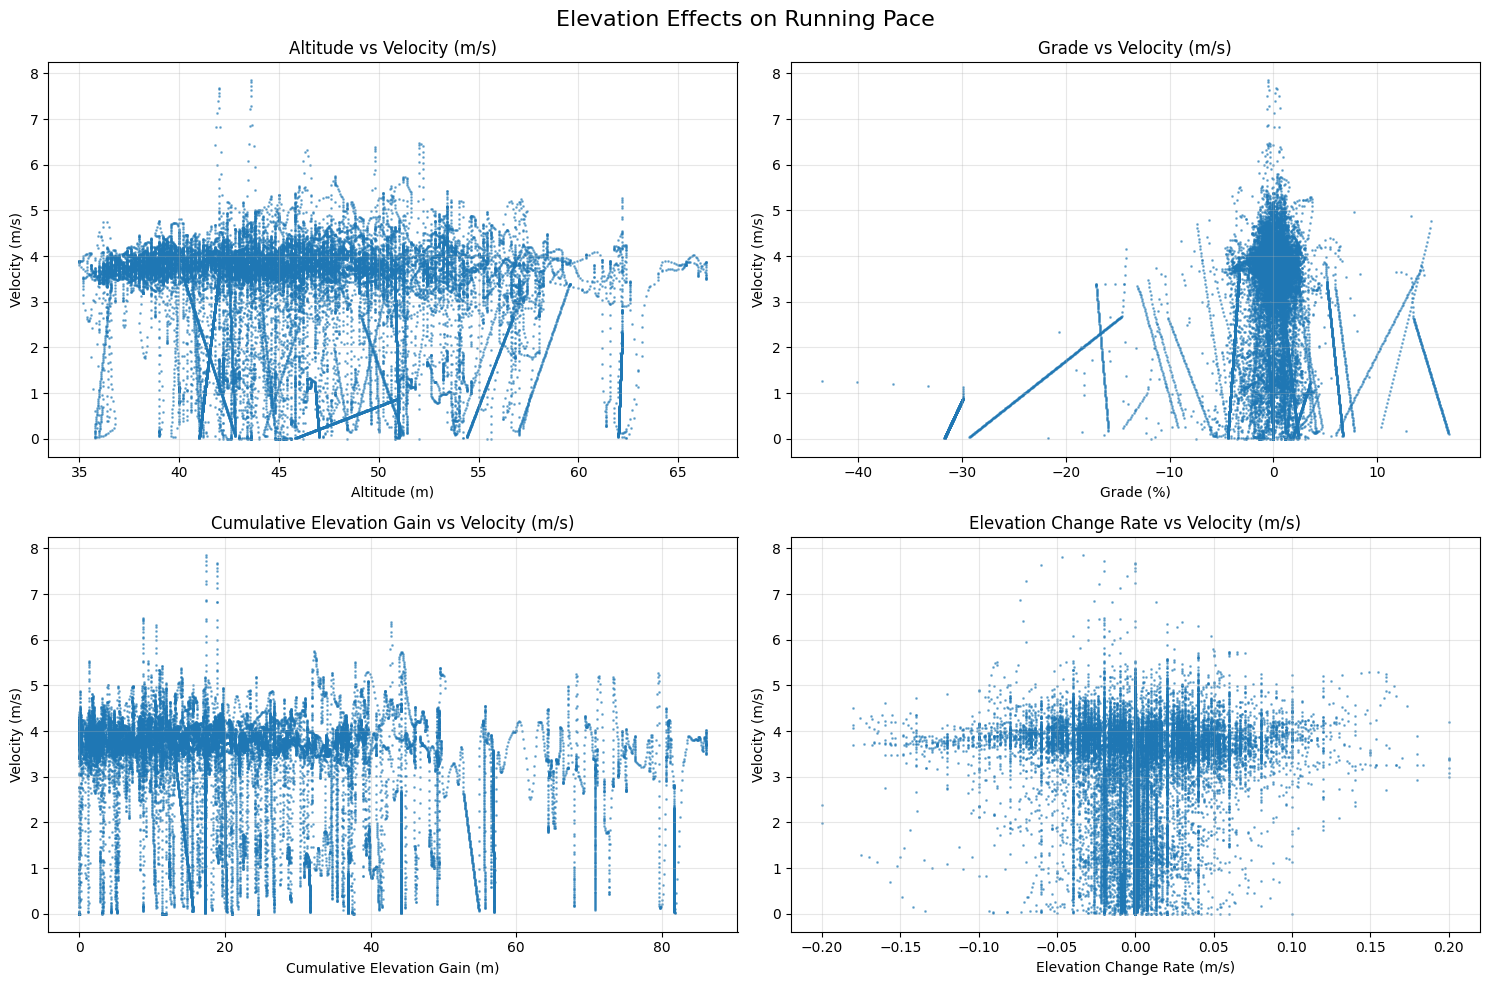

Correlation between elevation metrics and velocity (m/s):
altitude_m: -0.150
grade_percent: 0.309
cumulative_elevation_gain_m: -0.273
diff_altitude_mps: 0.034


In [8]:
# Visualize how elevation affects pace
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Elevation Effects on Running Pace', fontsize=16)

# Plot 1: Altitude vs Pace Efficiency
axes[0, 0].scatter(data['altitude_m'], data['smooth_velocity_mps'], alpha=0.5, s=1)
axes[0, 0].set_xlabel('Altitude (m)')
axes[0, 0].set_ylabel('Velocity (m/s)')
axes[0, 0].set_title('Altitude vs Velocity (m/s)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Grade vs Pace Efficiency
axes[0, 1].scatter(data['grade_percent'], data['smooth_velocity_mps'], alpha=0.5, s=1)
axes[0, 1].set_xlabel('Grade (%)')
axes[0, 1].set_ylabel('Velocity (m/s)')
axes[0, 1].set_title('Grade vs Velocity (m/s)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Cumulative Elevation Gain vs Pace Efficiency
axes[1, 0].scatter(data['cumulative_elevation_gain_m'], data['smooth_velocity_mps'], alpha=0.5, s=1)
axes[1, 0].set_xlabel('Cumulative Elevation Gain (m)')
axes[1, 0].set_ylabel('Velocity (m/s)')
axes[1, 0].set_title('Cumulative Elevation Gain vs Velocity (m/s)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Elevation Change Rate vs Pace Efficiency
axes[1, 1].scatter(data['diff_altitude_mps'], data['smooth_velocity_mps'], alpha=0.5, s=1)
axes[1, 1].set_xlabel('Elevation Change Rate (m/s)')
axes[1, 1].set_ylabel('Velocity (m/s)')
axes[1, 1].set_title('Elevation Change Rate vs Velocity (m/s)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("Correlation between elevation metrics and velocity (m/s):")
elevation_cols = ['altitude_m', 'grade_percent', 'cumulative_elevation_gain_m', 'diff_altitude_mps']
for col in elevation_cols:
    corr = data[col].corr(data['smooth_velocity_mps'])
    print(f"{col}: {corr:.3f}")

## Mathematical Models

In [ ]:
# params (from paper)
# this is where I initialize parameters for the mathematical model
# tau = 0.892  # time constant (s)
# initial_energy = 2409  # initial energy (m^2/s^2)
# sigma = 41.6 # energy conversion factor (m^2/s^3)

tau = 0.739             # time constant (s)
initial_energy = 3114   # initial energy (m^2/s^2)
sigma = 58.0            # energy conversion factor (m^2/s^3)
k = (4.08e-5)/2         # fatigue parameter (1/s)

    

# # initial values
# initial_heart_rate = 70  # initial heart rate (bpm)
# initial_velocity = 3.0  # initial velocity (m/s)

v0 = 1.0  # initial velocity (m/s)
E0 = initial_energy  # initial energy (m^2/s^2)

v = [0, v0]
# dv = [0]
E = [E0]
# dE = []

for t in range(0, 50):
    E.append(sigma - k*sum((v[i+1] - v[i])*v[i] + 1/tau *v[i]**2 for i in range(len(v)-1)) )
